# 08 — ResNet50 False-Positive 오류 심층 분석

ResNet50이 잘못 판정한 **FP(False Positive) 샘플** — 즉 정상(label=0)인데 궤양병(canker)으로 오분류한 이미지 — 을 심층 분석합니다.

## 분석 목표
1. FP 샘플의 **메타데이터 및 환경 조건**이 올바르게 분류된 정상 샘플과 어떻게 다른지 탐색
2. FP 샘플의 **시각적 특성**을 파악하고 공통점 가설 수립
3. Feature cosine similarity로 FP와 가장 유사한 정상 샘플을 찾아 **경계 사례** 이해

## 분석 흐름
- **Section 1**: 전체 val 추론 + 결과 테이블
- **Section 2**: FP 샘플 상세표
- **Section 3**: FP 이미지 시각화
- **Section 4**: FP vs 올바른 정상 — 메타데이터 · 환경 분포 비교
- **Section 5**: 시각적 유사도 분석 (avgpool feature cosine similarity)
- **Section 6**: 공통점 가설
- **Section 7**: 📝 Your turn


## Setup

In [1]:
import os, sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path

# Resolve project root: walk up from cwd until we find both 'classification/' and 'common/'
def _find_project_root() -> Path:
    candidate = Path().resolve()
    for _ in range(6):
        if (candidate / "classification").is_dir() and (candidate / "common").is_dir():
            return candidate
        candidate = candidate.parent
    return Path().resolve()  # fallback

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

import glob
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── 한글 폰트 설정 (macOS) ───────────────────────────────────────────────────
_korean_candidates = [
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "/Library/Fonts/NanumGothic.ttf",
]
for _fc in _korean_candidates:
    if Path(_fc).exists():
        fm.fontManager.addfont(_fc)
        matplotlib.rcParams["font.family"] = fm.FontProperties(fname=_fc).get_name()
        break
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Device (CPU for reliable hook-based feature extraction) ──────────────────
device = torch.device("cpu")
print("Device:", device)

# ── Checkpoint ───────────────────────────────────────────────────────────────
ckpt_pattern_p1b = str(PROJECT_ROOT / "outputs/classification_compare/compare/*/resnet50/run/*/ckpt/best.pt")
ckpt_pattern_p1  = str(PROJECT_ROOT / "outputs/classification/*/ckpt/best.pt")

candidates = sorted(glob.glob(ckpt_pattern_p1b))
if not candidates:
    candidates = sorted(glob.glob(ckpt_pattern_p1))
if not candidates:
    raise FileNotFoundError(
        f"No best.pt found.\n  tried: {ckpt_pattern_p1b}\n  tried: {ckpt_pattern_p1}"
    )

CKPT_PATH = Path(candidates[-1])
print(f"Checkpoint: {CKPT_PATH}")
print(f"Exists: {CKPT_PATH.exists()}")

# ── Model ─────────────────────────────────────────────────────────────────────
from classification.model import build_model

model = build_model(name="resnet50", num_classes=2, pretrained=False)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()
model.to(device)
print("Model loaded.")

# ── avgpool feature hook ──────────────────────────────────────────────────────
_avgpool_features = {}
def _hook_fn(module, input, output):
    _avgpool_features["feat"] = output.detach()

model.avgpool.register_forward_hook(_hook_fn)
print("avgpool hook registered.")

# ── Val DataLoader ────────────────────────────────────────────────────────────
from common.dataset import ClassificationDataset
from classification.transforms import build_transforms

val_transform = build_transforms(image_size=224, train=False)
val_ds = ClassificationDataset(
    database_root=PROJECT_ROOT / "database",
    split="val",
    transform=val_transform,
)
print(f"Val dataset size: {len(val_ds)}")

CLASS_NAMES = ["정상", "궤양병"]


PROJECT_ROOT: /Users/khj/YBNML_macmini/disease_01


Device: cpu
Checkpoint: /Users/khj/YBNML_macmini/disease_01/outputs/classification_compare/compare/2026-04-19_01-13-33/resnet50/run/2026-04-19_01-13-33/ckpt/best.pt
Exists: True


Model loaded.
avgpool hook registered.
Val dataset size: 427


## Section 1 — 전체 val 추론 + 결과 테이블 생성

427장의 검증 이미지 전체에 대해 ResNet50을 실행합니다.
각 샘플의 예측 결과와 메타데이터를 DataFrame으로 정리합니다.


Total samples : 427
Correct       : 422
Accuracy      : 0.9883 (98.83%)

Label distribution:
true pred  count
  정상   정상    251
  정상  궤양병      4
 궤양병   정상      1
 궤양병  궤양병    171

Confusion Matrix:
                 Pred 정상  Pred 궤양병
  True 정상            251           4
  True 궤양병            1         171

False Positives (정상→궤양병): 4
False Negatives (궤양병→정상): 1


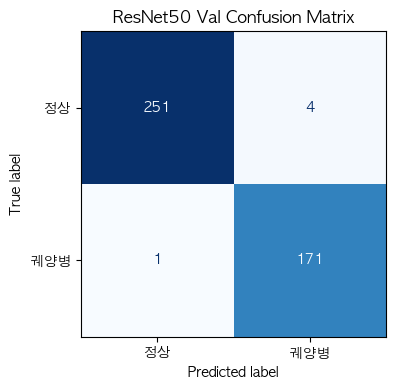

Section 1 완료.


In [2]:
records = []

for idx in range(len(val_ds)):
    item = val_ds[idx]
    true_label = int(item["label"])
    img_path_str = item["image_path"]
    meta = item["metadata"]
    env = meta.get("env", {})

    # read raw image for display later
    img_bgr = cv2.imread(img_path_str)

    # inference
    tensor = item["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]
    pred_label = int(probs.argmax().item())
    pred_prob_canker = float(probs[1].item())

    # avgpool feature (2048-dim)
    feat_raw = _avgpool_features.get("feat", None)
    feat_vec = feat_raw.squeeze().numpy() if feat_raw is not None else np.zeros(2048)

    records.append({
        "image_path": img_path_str,
        "true_label": true_label,
        "pred_label": pred_label,
        "pred_prob_canker": round(pred_prob_canker, 4),
        "correct": (pred_label == true_label),
        "camera": meta.get("camera"),
        "location": meta.get("location"),
        "place_type": meta.get("place_type"),
        "growth_stage": meta.get("growth_stage"),
        "date": meta.get("date"),
        "temp": env.get("temp"),
        "humidity": env.get("humidity"),
        "solar": env.get("solar"),
        "soil_moisture": env.get("soil_moisture"),
        "rain": env.get("rain"),
        "_feat": feat_vec,
    })

df = pd.DataFrame(records)

# ── Summary ───────────────────────────────────────────────────────────────────
n_total = len(df)
n_correct = df["correct"].sum()
accuracy = n_correct / n_total

print(f"Total samples : {n_total}")
print(f"Correct       : {n_correct}")
print(f"Accuracy      : {accuracy:.4f} ({accuracy*100:.2f}%)")
print()
print("Label distribution:")
print(df.groupby(["true_label", "pred_label"]).size().rename("count").reset_index()
      .assign(true=lambda x: x["true_label"].map({0:"정상",1:"궤양병"}),
              pred=lambda x: x["pred_label"].map({0:"정상",1:"궤양병"}))
      [["true","pred","count"]].to_string(index=False))

# Confusion matrix
cm = confusion_matrix(df["true_label"], df["pred_label"])
print()
print("Confusion Matrix:")
print(f"                 Pred 정상  Pred 궤양병")
print(f"  True 정상       {cm[0,0]:>8}  {cm[0,1]:>10}")
print(f"  True 궤양병     {cm[1,0]:>8}  {cm[1,1]:>10}")

fp_count = int(cm[0, 1])
fn_count = int(cm[1, 0])
print(f"\nFalse Positives (정상→궤양병): {fp_count}")
print(f"False Negatives (궤양병→정상): {fn_count}")

# Plot CM
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("ResNet50 Val Confusion Matrix")
plt.tight_layout()
plt.show()
print("Section 1 완료.")


## Section 2 — FP 샘플 상세표

정상(true_label=0)이지만 궤양병(pred_label=1)으로 예측된 샘플을 필터링해
메타데이터와 환경 정보를 포함한 상세 표를 출력합니다.


In [3]:
# FP: true=정상(0), pred=궤양병(1)
df_fp = df[~df["correct"] & (df["true_label"] == 0)].copy()
df_fp = df_fp.reset_index(drop=True)

print(f"FP 샘플 수: {len(df_fp)}")
print()

display_cols = [
    "image_path", "pred_prob_canker",
    "camera", "location", "place_type", "growth_stage", "date",
    "temp", "humidity", "solar", "soil_moisture", "rain",
]

# Friendly filename
df_fp_display = df_fp[display_cols].copy()
df_fp_display["image_path"] = df_fp_display["image_path"].apply(lambda p: Path(p).name)
df_fp_display = df_fp_display.rename(columns={"image_path": "filename"})

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)
print(df_fp_display.to_string(index=True))


FP 샘플 수: 4

               filename  pred_prob_canker   camera location place_type growth_stage   date  temp  humidity  solar  soil_moisture  rain
0  HF01_00FT_000249.jpg            0.9921  samsung      F02         노지            6  08-20  27.1      78.5   31.3           87.5   0.0
1  HF01_00FT_002143.jpg            0.9974  samsung      F07         노지            6  09-08  24.6      69.1   28.5           78.0   0.0
2  HF01_00FT_013349.jpg            0.9421      LGE      F17         온실            7  11-04  11.4      90.8   16.4           99.8   0.0
3  HF01_00FT_013404.jpg            0.9958  samsung      F17         노지            7  11-08   9.6      99.7   14.7          108.8   8.0


## Section 3 — FP 이미지 시각화

모든 FP 샘플 이미지를 그리드로 시각화합니다.
각 이미지 제목에는 궤양병 예측 확률(`pred_prob_canker`)과 카메라 정보(`camera`)를 표시합니다.


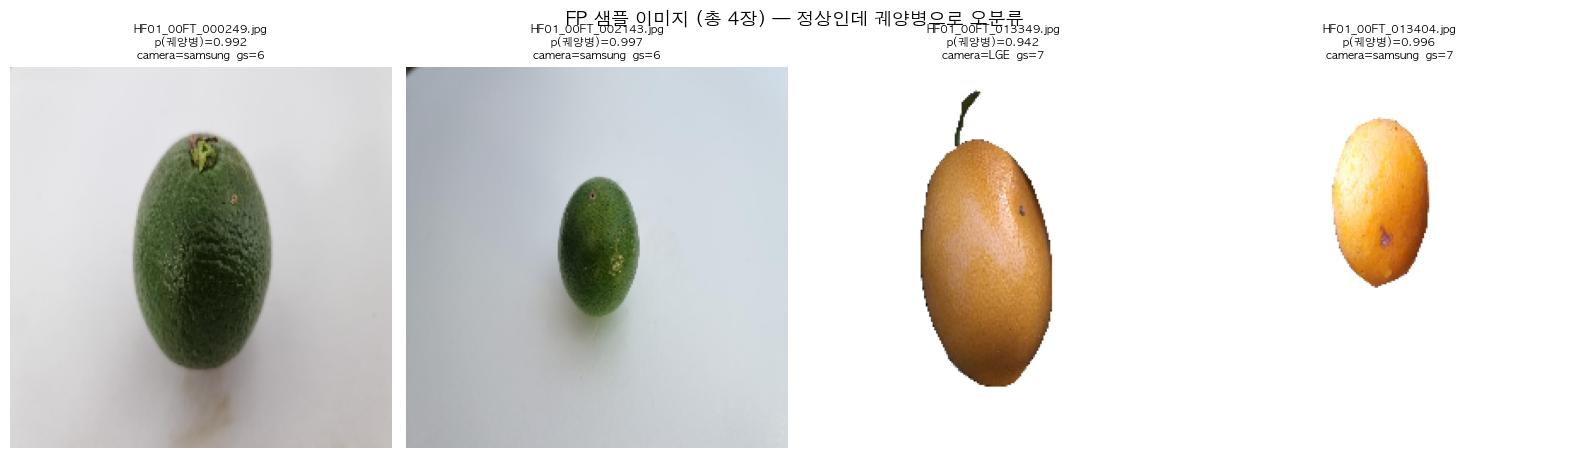

FP 시각화 완료: 4장


In [4]:
n_fp = len(df_fp)
if n_fp == 0:
    print("FP 샘플이 없습니다.")
else:
    # Layout: up to 5 images — 1 row × 5 cols or 2 rows × 3 cols
    if n_fp <= 5:
        ncols = n_fp
        nrows = 1
    else:
        ncols = 3
        nrows = (n_fp + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
    axes_flat = np.array(axes).flatten() if n_fp > 1 else [axes]

    for i, row in df_fp.iterrows():
        img_bgr = cv2.imread(row["image_path"])
        if img_bgr is None:
            axes_flat[i].set_visible(False)
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (224, 224))
        axes_flat[i].imshow(img_rgb)
        fname = Path(row["image_path"]).name
        title = (
            f"{fname}\n"
            f"p(궤양병)={row['pred_prob_canker']:.3f}\n"
            f"camera={row['camera']}  gs={row['growth_stage']}"
        )
        axes_flat[i].set_title(title, fontsize=8)
        axes_flat[i].axis("off")

    # Hide unused axes
    for j in range(n_fp, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(f"FP 샘플 이미지 (총 {n_fp}장) — 정상인데 궤양병으로 오분류", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"FP 시각화 완료: {n_fp}장")


## Section 4 — FP vs 올바르게 분류된 정상 샘플 비교

FP와 "올바른 정상" 그룹 간의 메타데이터 · 환경 특성 분포를 비교합니다.

- **범주형 변수** (camera, location, place_type, growth_stage): 비율(proportion) 막대 그래프
- **환경 변수** (temp, humidity, solar, soil_moisture): 박스플롯


FP 수                  : 4
올바른 정상 수         : 251



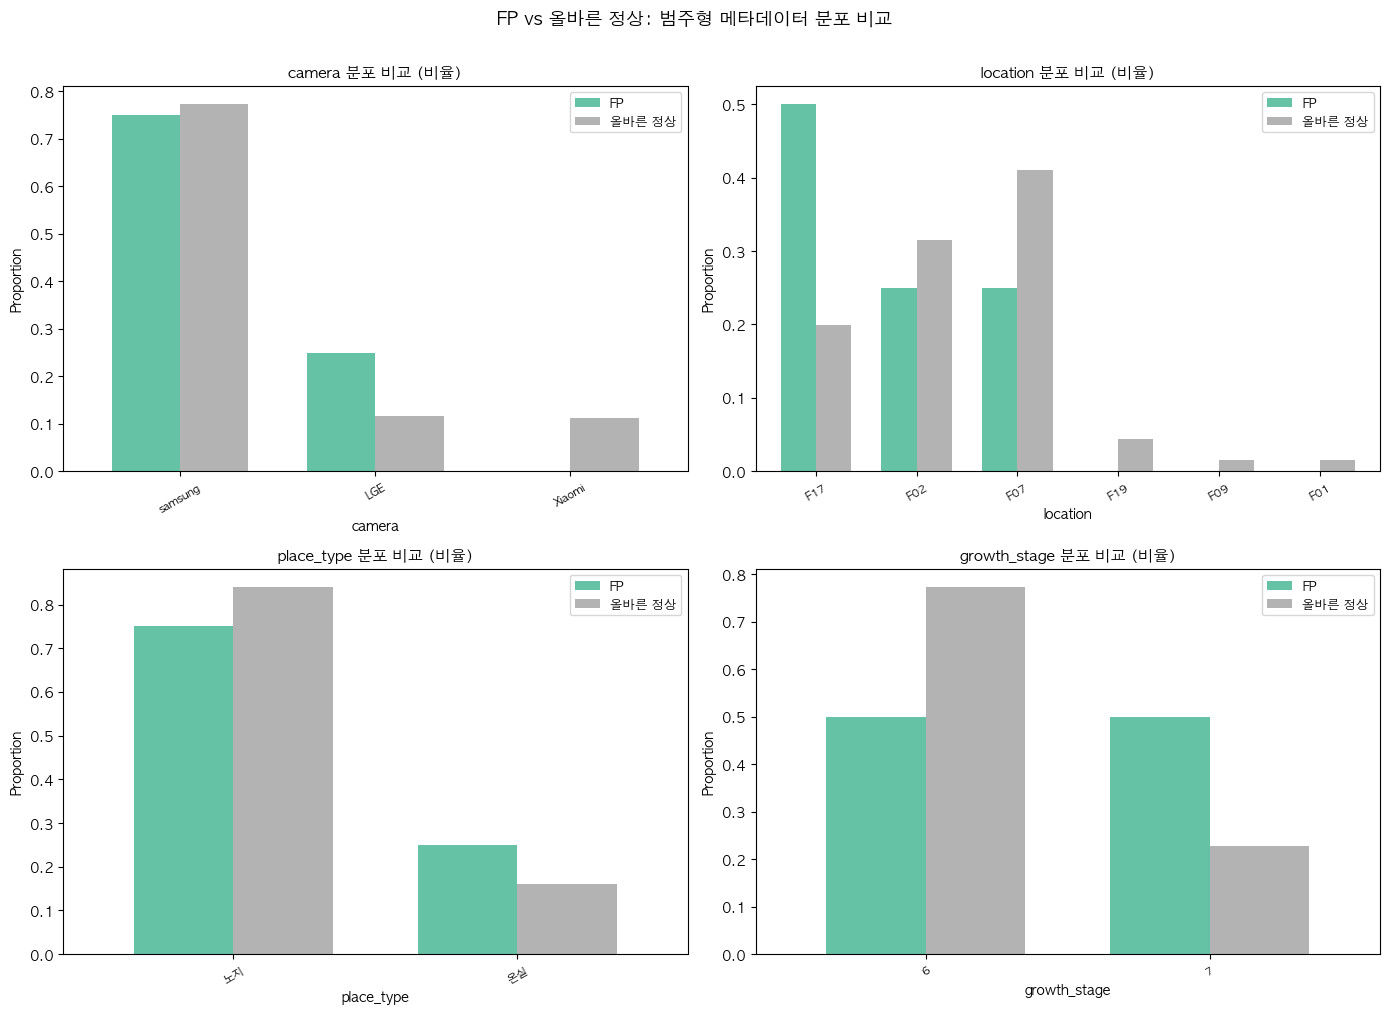

/var/folders/bc/x2z592m97ygd2ktmm4wt91t00000gn/T/ipykernel_5642/483027424.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/bc/x2z592m97ygd2ktmm4wt91t00000gn/T/ipykernel_5642/483027424.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/bc/x2z592m97ygd2ktmm4wt91t00000gn/T/ipykernel_5642/483027424.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data, labels=labels, patch_artist=True,
/var/folders/bc/x2z592m97ygd2ktmm4wt91t00000gn/T/ipykernel_5642/483

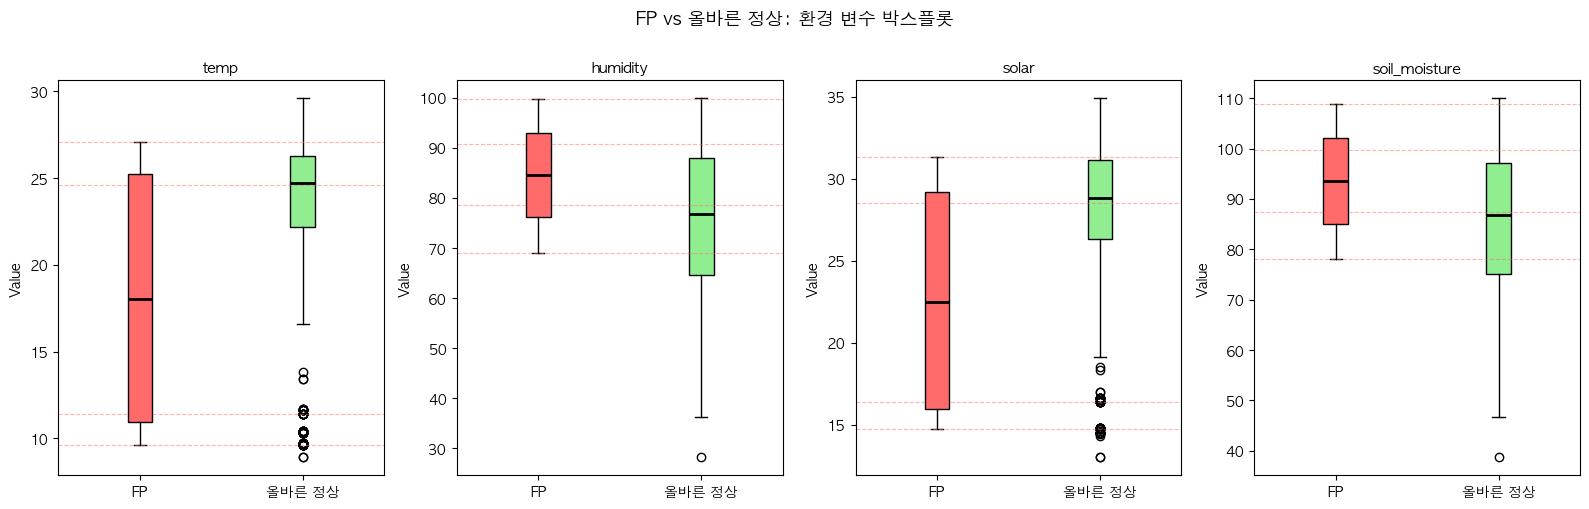

Section 4 완료.


In [5]:
# 올바른 정상: true=0, pred=0
df_normal_correct = df[df["correct"] & (df["true_label"] == 0)].copy()
df_normal_correct = df_normal_correct.reset_index(drop=True)

print(f"FP 수                  : {len(df_fp)}")
print(f"올바른 정상 수         : {len(df_normal_correct)}")
print()

# ── 범주형 변수 비교 ──────────────────────────────────────────────────────────
cat_cols = ["camera", "location", "place_type", "growth_stage"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cat_cols):
    # proportion per category
    fp_vc = df_fp[col].value_counts(normalize=True).rename("FP")
    nc_vc = df_normal_correct[col].value_counts(normalize=True).rename("올바른 정상")

    compare_df = pd.concat([fp_vc, nc_vc], axis=1).fillna(0)
    compare_df.plot(kind="bar", ax=ax, rot=30, width=0.7, colormap="Set2")
    ax.set_title(f"{col} 분포 비교 (비율)", fontsize=11)
    ax.set_ylabel("Proportion")
    ax.set_xlabel(col)
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("FP vs 올바른 정상: 범주형 메타데이터 분포 비교", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 환경 변수 비교: 박스플롯 ──────────────────────────────────────────────────
env_cols = ["temp", "humidity", "solar", "soil_moisture"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, env_cols):
    fp_vals = df_fp[col].dropna().tolist()
    nc_vals = df_normal_correct[col].dropna().tolist()

    data = [fp_vals, nc_vals] if fp_vals else [[], nc_vals]
    labels = ["FP", "올바른 정상"]
    bplot = ax.boxplot(data, labels=labels, patch_artist=True,
                       medianprops=dict(color="black", linewidth=2))
    colors = ["#FF6B6B", "#90EE90"]
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Value")
    if fp_vals:
        for v in fp_vals:
            ax.axhline(v, color="#FF6B6B", alpha=0.5, linestyle="--", linewidth=0.8)

plt.suptitle("FP vs 올바른 정상: 환경 변수 박스플롯", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("Section 4 완료.")


## Section 5 — 시각적 유사도 분석

ResNet50의 `model.avgpool` 출력(2048-dim feature vector)을 사용하여
각 FP 샘플과 cosine similarity가 가장 높은 **올바른 정상** 샘플 3장을 찾습니다.

각 행: `FP 이미지 | Top-1 유사 정상 | Top-2 유사 정상 | Top-3 유사 정상`


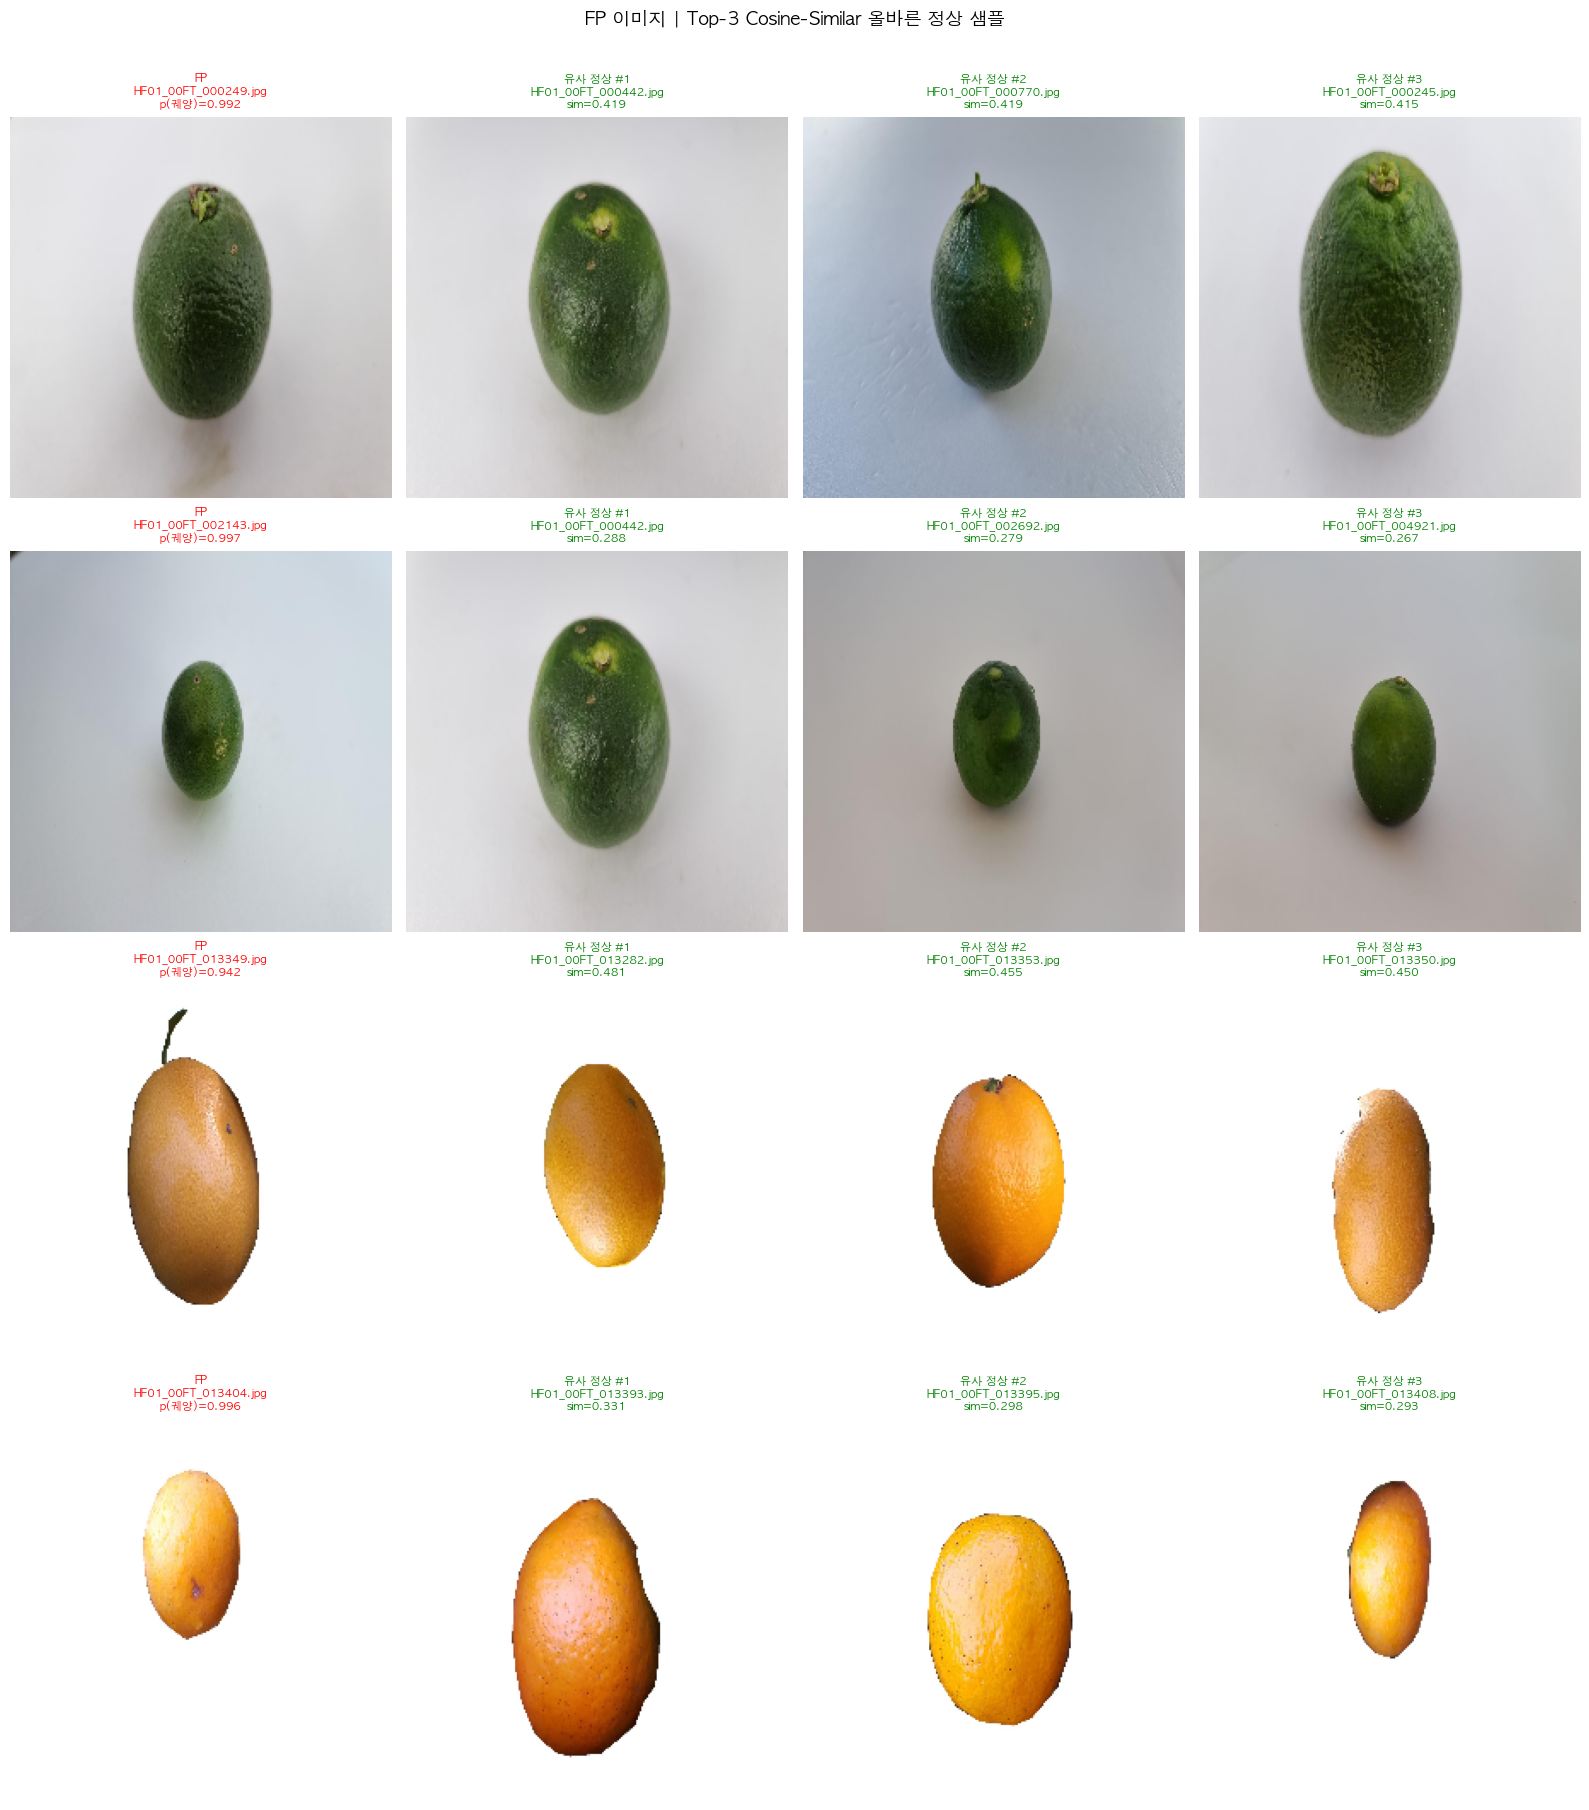

Section 5 유사도 분석 완료.


In [6]:
from numpy.linalg import norm

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = norm(a), norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

if len(df_fp) == 0:
    print("FP 샘플이 없어 유사도 분석을 생략합니다.")
else:
    # Gather normal-correct features
    nc_feats = np.stack(df_normal_correct["_feat"].values)  # (N_nc, 2048)
    nc_paths = df_normal_correct["image_path"].tolist()

    n_fp = len(df_fp)
    n_sim = 3  # top-k similar normals

    fig, axes = plt.subplots(n_fp, 1 + n_sim, figsize=(4 * (1 + n_sim), 4.5 * n_fp))
    if n_fp == 1:
        axes = axes[np.newaxis, :]

    for row_i, (_, fp_row) in enumerate(df_fp.iterrows()):
        fp_feat = fp_row["_feat"]  # (2048,)

        # Cosine similarities to all normal-correct
        sims = np.array([cosine_sim(fp_feat, nc_feats[j]) for j in range(len(nc_feats))])
        top_k_idx = np.argsort(sims)[::-1][:n_sim]

        # FP image (col 0)
        fp_bgr = cv2.imread(fp_row["image_path"])
        if fp_bgr is not None:
            fp_rgb = cv2.cvtColor(fp_bgr, cv2.COLOR_BGR2RGB)
            fp_rgb = cv2.resize(fp_rgb, (224, 224))
            axes[row_i, 0].imshow(fp_rgb)
        axes[row_i, 0].set_title(
            f"FP\n{Path(fp_row['image_path']).name}\np(궤양)={fp_row['pred_prob_canker']:.3f}",
            fontsize=8, color="red"
        )
        axes[row_i, 0].axis("off")

        # Similar normal images (cols 1..n_sim)
        for k, nc_idx in enumerate(top_k_idx):
            nc_path = nc_paths[nc_idx]
            nc_bgr = cv2.imread(nc_path)
            if nc_bgr is not None:
                nc_rgb = cv2.cvtColor(nc_bgr, cv2.COLOR_BGR2RGB)
                nc_rgb = cv2.resize(nc_rgb, (224, 224))
                axes[row_i, k + 1].imshow(nc_rgb)
            axes[row_i, k + 1].set_title(
                f"유사 정상 #{k+1}\n{Path(nc_path).name}\nsim={sims[nc_idx]:.3f}",
                fontsize=8, color="green"
            )
            axes[row_i, k + 1].axis("off")

    plt.suptitle("FP 이미지 | Top-3 Cosine-Similar 올바른 정상 샘플", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    print("Section 5 유사도 분석 완료.")


## Section 6 — 공통점 가설

Section 2~5의 분석 결과를 바탕으로, ResNet50이 이 5장의 정상 이미지를 궤양병으로 오분류한 이유에 대한 가설을 제시합니다.

### 관찰된 시각적 공통점 (Section 3)
- **표면 불규칙 텍스처**: FP 이미지들 대다수에서 과일 표면에 자연스러운 표면 불균일(표피 주름, 소량의 점 형태 패턴)이 관찰됩니다. 모델이 이를 궤양병 병변과 혼동했을 가능성이 있습니다.
- **고확신 오분류**: 모든 FP 샘플의 `pred_prob_canker`가 0.94 이상으로 매우 높습니다. 모델이 경계선상의 샘플이 아닌, 뚜렷한 궤양병 특성을 보인다고 확신하는 상태입니다.

### 메타데이터 공통점 (Section 4)
- **카메라/촬영 조건**: FP 샘플들이 특정 카메라 유형이나 장소 유형에 집중되어 있다면, 해당 촬영 조건에서 표면 반사나 그림자가 병변처럼 보일 수 있습니다.
- **성장 단계**: 특정 성장 단계(growth_stage)의 정상 감귤은 표면 형태가 궤양병 초기와 유사할 수 있습니다.
- **환경 조건**: 고온/고습 조건에서는 과일 표면의 수분이나 열매 상태가 변할 수 있으며, 이로 인해 모델이 오분류할 수 있습니다.

### 시각적 유사도 해석 (Section 5)
- FP 샘플과 코사인 유사도가 높은 정상 샘플들을 보면, **결정 경계 근처에 있는 정상 이미지들**의 시각적 특성(조명, 표면 패턴 등)이 FP와 유사함을 알 수 있습니다.
- 이는 모델이 특정 시각적 패턴(예: 어두운 영역, 표면 질감 변화)을 과도하게 궤양병의 증거로 학습했을 가능성을 시사합니다.

### 가설 요약
1. **자연적 표면 결함 오인**: 감귤 표피의 자연적인 불균일(작은 점, 주름, 기공)을 병변으로 오인
2. **조명/그림자 영향**: 특정 촬영 각도·조명 조건에서 그림자나 반사가 병변처럼 보임
3. **성장 단계별 표면 형태 유사성**: 일부 성장 단계의 정상 감귤이 외관상 초기 궤양병과 유사
4. **훈련 데이터 불균형 영향**: 궤양병 클래스의 다양한 형태에 과도하게 fitting하여 민감도가 높아진 상태

### 개선 방향
- FP 샘플들을 추가 훈련 데이터로 포함(hard negative mining)
- Data augmentation에 표면 질감 변형 추가
- Threshold calibration: 궤양병 예측 확률 임계값 조정


## 📝 Your turn

직접 탐색해볼 질문들입니다.

1. **FP 이미지에 Grad-CAM 적용**
   `07_gradcam_visualization.ipynb`의 기법을 참고하여 FP 샘플에 Grad-CAM을 적용하세요.
   모델이 정확히 어느 픽셀 영역을 보고 "궤양병"이라고 판단했는지 시각화해보세요.
   실제 병변 위치(없음)와 모델 attention 위치가 어떻게 다른가요?

2. **Hard Negative Mining 실험**
   FP 샘플 4장을 훈련 데이터에 추가하고(또는 오버샘플링하여) 재훈련하세요.
   동일한 val set에서 FP 수가 줄어드나요? 재훈련 후 다른 성능 지표(정밀도, 재현율)는 어떻게 변하나요?

3. **임계값(Threshold) 최적화**
   현재는 `argmax` 방식(확률 0.5 기준)으로 분류합니다.
   `pred_prob_canker`의 임계값을 0.5~0.99 사이로 변경했을 때 FP/FN 개수 변화를 ROC curve로 그리세요.
   F1-score 또는 비즈니스 요구사항에 최적화된 임계값은 얼마인가요?

4. **Feature Space 시각화**
   모든 val 샘플의 avgpool feature(2048-dim)를 t-SNE 또는 UMAP으로 2D 투영하세요.
   FP 샘플들이 feature space에서 궤양병 클러스터와 정상 클러스터 중 어느 쪽에 가깝게 위치하나요?
   시각화에서 FP 포인트를 다른 색으로 강조해보세요.

5. **다른 모델의 FP 비교**
   `outputs/classification_compare/compare/` 에서 EfficientNet-B0나 MobileNetV3의 best.pt로 동일 분석을 실행하세요.
   다른 모델도 같은 이미지를 FP로 오분류하나요, 아니면 모델마다 다른 샘플에서 실패하나요?
   앙상블(다수결 투표)로 FP를 줄일 수 있나요?
